## 0) Imports and stuff

In [1]:
""" from google.colab import drive
drive.mount('/content/drive') """

" from google.colab import drive\ndrive.mount('/content/drive') "

In [2]:
# cd "drive/MyDrive/tests-sara"

In [1]:

%load_ext autoreload
%autoreload 2


In [2]:
from data_processing.dataloader import get_BAA_DFS
from data_processing.dataset import BAA_Dataset
from data_processing.preprocessing import get_transforms
from model.model import BAA_resnet18
from model.train import train_model
from model.eval import evaluate
from model.gradcam import GradCAM

from torch.utils.data import DataLoader
import torch
import matplotlib.pyplot as plt
import numpy as np
from os import path, listdir, getcwd
from pathlib import Path
from PIL import Image

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device: {}'.format(device))

Device: cuda


## 1) Data preparation

In [8]:
batch_size = 64
num_workers = 6

target_image_size = (150, 100)

### 1.1) Loading data

In [9]:
## wherever you stored data: this folder needs to have the .csv, and you need to specify folder names for where to get ur images
## if you don't want to apply segmentation, just set the flag to false and make sure the image files are named as in RSNA
## if you don't have have one just put none -> will download with kagglehub library
apply_segmentation = True
datapath = path.join(getcwd(), "data")

In [10]:
# you will need to include kagglehub in dependencies if folders don't exist
train_df, val_df = get_BAA_DFS(datapath = datapath, image_folder = "masks", apply_segmentation = apply_segmentation)

checking apply seg:
checking apply seg:
finished checking

Full df size len: 1626
train/val sizes: 1300/326


### 1.2) Transforms

In [11]:
transforms = get_transforms(target_image_size)

np.float64(0.22129011581936486)

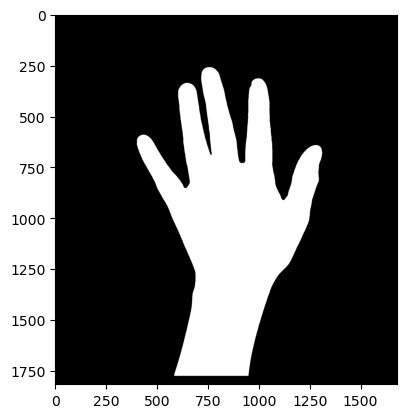

In [12]:
img  = np.asarray(Image.open(val_df["mask_path"].iloc[25]))
plt.imshow(img, cmap='gray')
w = np.count_nonzero(img)
t = img.shape[0] * img.shape[1]
w / t

### 1.3) Dataset

In [15]:
train_dataset = BAA_Dataset(train_df, transforms, apply_segmentation = apply_segmentation)
val_dataset = BAA_Dataset(val_df, transforms, apply_segmentation)

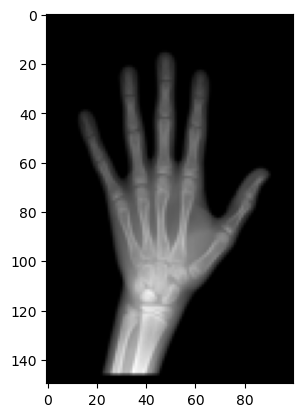

In [16]:
img, _, _ = val_dataset.__getitem__(0)
img = img.squeeze(0).cpu()
plt.imshow(img, cmap='gray')

### 1.4) DataLoader

In [17]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

## 2) Model

### 2.1) Initial Resnet18

In [18]:
model = BAA_resnet18().to(device)
model_type = 'resnet18'

### 2.2) Loading a Checkpoint

In [19]:
checkpoint_path = path.join(getcwd(), "model", "checkpoints")
specific_checkpoint = f"checkpoint{9}.pth"

In [ ]:
p = path.join(checkpoint_path, specific_checkpoint)
if path.exists(p):
    checkpoint = torch.load(p, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"checkpoint best mae: {checkpoint['mae']}")
else:
    print("checkpoint doesn't exist")

## 3) Training

In [21]:
learning_rate = 0.01
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate)
criterion = torch.nn.L1Loss()
n_epochs = 5


### 3.1) Training loop

In [22]:
train_losses = []
val_losses = []

In [23]:
# train_losses, val_losses = train_model(model, train_dataloader, val_dataloader, n_epochs, device, optimizer, criterion, checkpoint_path)

### 3.2) Eval only

In [24]:
mae = None
# mae = evaluate(model, val_dataloader, device, criterion)

In [25]:
# print(mae)

### 3.3) Visualizing results

In [26]:
if len(val_losses) > 0:
    print(train_losses[-1], val_losses[-1])

    mae = val_losses / val_dataset.shape[0]
    
    plt.figure()
    plt.plot(np.arange(len(train_losses)), train_losses)
    plt.plot(np.arange(len(val_losses)), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value (boneage months)')
    plt.title('{}: Train/val loss'.format("current model training results"));

### 3.4) Saving current model

In [27]:
specific_checkpoint = f"checkpoint-{model_type}.pth"

In [28]:
"""
p = path.join(checkpoint_path, specific_checkpoint)
state_dict = model.state_dict()

if mae is None:
    mae = evaluate(model, val_dataloader, device, criterion)

if path.exists(p):

    checkp = torch.load(p, weights_only=False)
    if checkp['mae'] < mae:
        print('new model sucks')
        state_dict = checkp['model_state_dict']



torch.save({
    'model_state_dict': model.state_dict(),
    'mae': mae
}, p)
"""

"\np = path.join(checkpoint_path, specific_checkpoint)\nstate_dict = model.state_dict()\n\nif mae is None:\n    mae = evaluate(model, val_dataloader, device, criterion)\n\nif path.exists(p):\n\n    checkp = torch.load(p, weights_only=False)\n    if checkp['mae'] < mae:\n        print('new model sucks')\n        state_dict = checkp['model_state_dict']\n\n\n\ntorch.save({\n    'model_state_dict': model.state_dict(),\n    'mae': mae\n}, p)\n"

## 4) GRAD-Cam

### 4.1) Set the target layer
You need to define the target layer: usually the last convolutional layer from whichever backbone model you chose.
For Restnet 18, it's divided into 4 "blocks" of layers, we want the last layer of the last block. I specify it inside the model class as it depends on backbone architecture

In [29]:
target_layer = model.gradcam_target_layer

### 4.2) Generate Grad-CAM

In [30]:
grad_cam = GradCAM(model, target_layer)

### 4.2) Apply it to a single input

In [31]:
img, gender, age, idx = val_dataset.get_random_items(1)[0]

In [32]:
u_img = img.unsqueeze(0).to(device)
u_gender = gender.unsqueeze(0).to(device)

print(f"img shape: {u_img.shape}, gender shape: {u_gender.shape}")

img shape: torch.Size([1, 1, 150, 100]), gender shape: torch.Size([1])


In [33]:
cam = grad_cam.generate(u_img, u_gender)
cam = cam.cpu()
resized_cam = grad_cam.resize_cam(cam, target_image_size)

In [34]:
pred = model(u_img, u_gender)

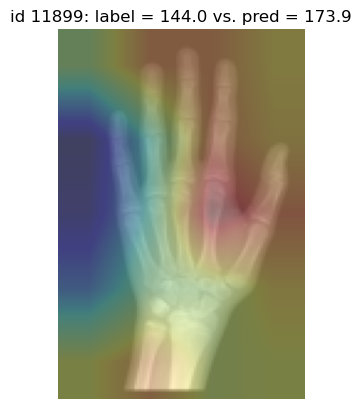

In [35]:
img = img.squeeze(0).cpu()
plt.imshow(resized_cam, cmap='jet_r', alpha=0.5)
plt.imshow(img, cmap='gray', alpha=0.5)
plt.axis('off')
plt.title(f"id {idx}: label = {age:.4} vs. pred = {pred.item():.4}")
plt.show()

### 4.3) Apply it to multiple inputs

In [36]:
rand_inputs = val_dataset.get_random_items(9)

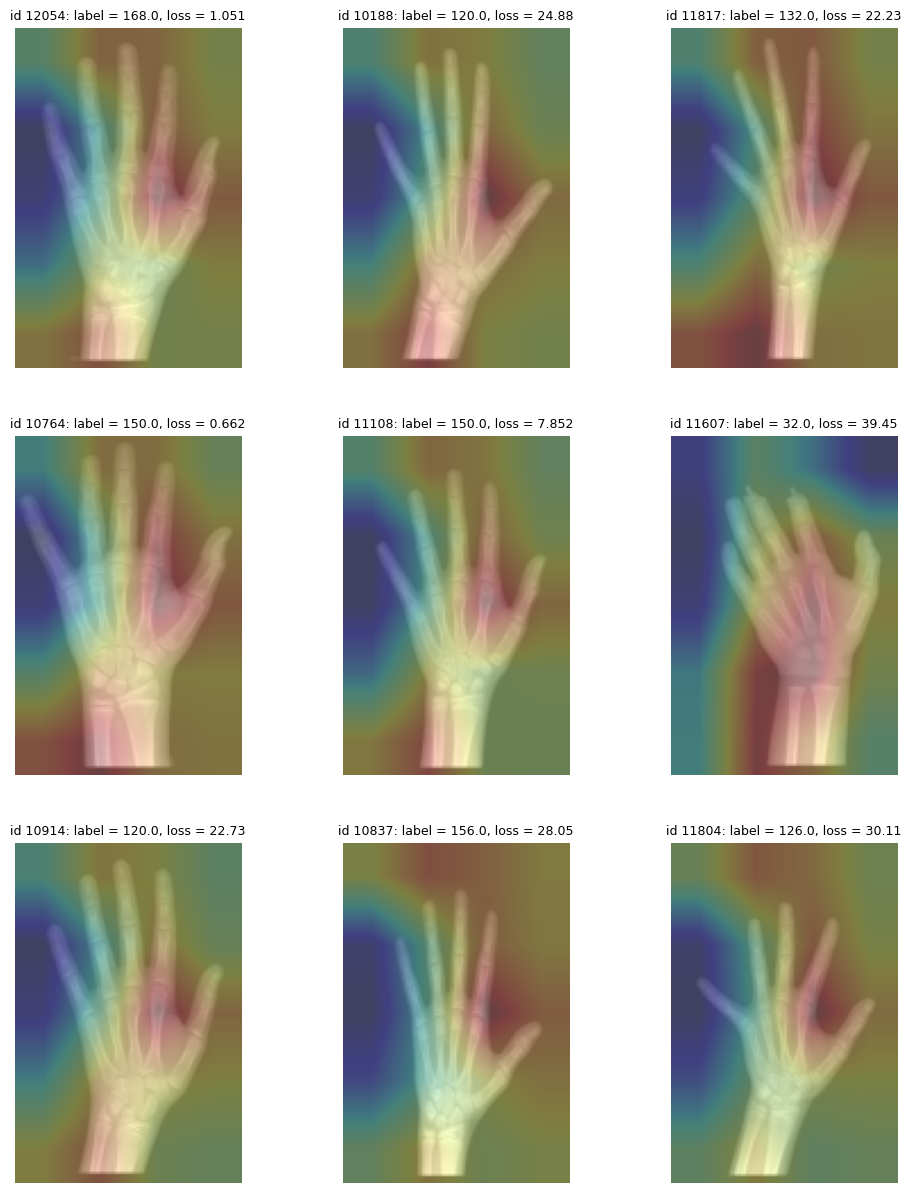

In [37]:
fig, ax = plt.subplots(nrows=3, ncols=3, sharex=True, sharey=False)
fig.set_figheight(15)
fig.set_figwidth(12)

for test_input, sub_plot in zip(rand_inputs, fig.axes):

    img, gender, age, idx = test_input
    u_img = img.unsqueeze(0).to(device)
    u_gender = gender.unsqueeze(0).to(device)

    cam = grad_cam.generate(u_img, u_gender)
    cam = cam.cpu()
    resized_cam = grad_cam.resize_cam(cam, target_image_size)

    pred = model(u_img, u_gender)

    img = img.squeeze(0).cpu()
    sub_plot.axis('off')
    sub_plot.imshow(resized_cam, cmap='jet_r', alpha=0.5)
    sub_plot.imshow(img, cmap='gray', alpha=0.5)
    sub_plot.set_title(f"id {idx}: label = {age:.4}, loss = {criterion(age, pred.squeeze(0)):.4}", fontsize = 9)